In [1]:
import numpy as np # linear algebra
import pandas as pd

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.Exited.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [6]:
df1=df.Gender=='Male'
df1.sum()

np.int64(5457)

In [7]:
df.Gender.value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [8]:
df.drop(columns=["RowNumber",'CustomerId','Surname'],inplace=True)

In [9]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [10]:
df=pd.get_dummies(df,columns=["Geography",'Gender'],drop_first=True)
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [11]:
X=df.drop(columns=['Exited'])
y=df.Exited
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)



In [12]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

In [13]:
X_train_traf=scaler.fit_transform(X_train)
X_test_traf=scaler.transform(X_test)

In [14]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [15]:
# model=Sequential()

# model.add(Dense(3,activation='sigmoid',input_dim=11))
# model.add(Dense(1,activation='sigmoid'))

In [16]:
model=Sequential()

model.add(Dense(10,activation='relu',input_dim=11))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

C:\Users\syedm\anaconda3\envs\eda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ dense (Dense)                 │ (None, 10)            │          120 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 10)            │          110 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_2 (Dense)               │ (None, 1)             │           11 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [19]:
history=model.fit(X_train_traf,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7594 - loss: 0.5378 - val_accuracy: 0.8037 - val_loss: 0.4634
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8123 - loss: 0.4448 - val_accuracy: 0.8131 - val_loss: 0.4402
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8197 - loss: 0.4296 - val_accuracy: 0.8213 - val_loss: 0.4316
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8253 - loss: 0.4219 - val_accuracy: 0.8238 - val_loss: 0.4256
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8258 - loss: 0.4162 - val_accuracy: 0.8219 - val_loss: 0.4205
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8286 - loss: 0.4112 - val_accuracy: 0.8250 - val_loss: 0.4150
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8288 - loss: 0.4058 - val_accuracy: 0.8263 - val_loss: 0.4095
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8336 - loss: 0.4002 - val_accu

In [20]:
model.layers[0].get_weights()

[array([[ 0.02939161, -0.5664939 , -0.18623383,  0.42179608, -0.06993328,
          0.0359824 , -0.21103658,  0.4012814 , -0.09252021, -0.34662074],
        [-0.35142726,  0.12065544,  0.20832431, -0.35748145,  0.32333183,
         -0.72227556,  1.0558382 ,  0.08937333,  1.0291333 , -0.04707541],
        [ 0.0597718 ,  0.41620278, -0.08754965,  0.00653682, -0.19898118,
         -0.12639   , -0.16925168, -0.32906675, -0.08586104, -0.50938773],
        [ 0.26931676, -0.73911935, -0.20967238,  0.2662247 ,  0.40099236,
          0.17696293,  0.32606828, -0.86493003,  0.10855793,  0.44967246],
        [ 0.27978545, -0.00968035, -1.2083294 , -1.0063562 ,  1.3078885 ,
         -0.22323382, -0.45103958, -0.073101  ,  1.1312764 , -0.34727597],
        [ 0.24634466, -0.19842431,  0.00936642, -0.1072779 , -0.1495392 ,
          0.07192636,  0.06360566, -0.2017795 , -0.05397099, -0.44116783],
        [ 0.20880145,  0.1674383 , -0.36302137,  0.04756336, -0.76788825,
         -0.34641734,  0.3732305

In [21]:
model.layers[1].get_weights()

[array([[-0.2945962 ,  0.23932326,  0.7215428 , -0.535219  ,  0.6599181 ,
         -0.38562196,  0.42197415,  0.25361916,  0.03062527, -0.00545092],
        [ 0.47831994, -0.5897642 ,  0.20051682,  0.2910778 ,  0.18624932,
          0.12325402,  0.10371991,  0.08006404,  0.09991314,  0.00530947],
        [-0.5163891 , -0.8259631 , -0.3090861 ,  0.4718396 , -0.5561843 ,
         -0.7116707 , -0.07468174,  0.7248214 , -0.5811653 , -0.41801798],
        [ 0.29016286,  0.39161158,  0.39142486,  0.16820009, -0.16310556,
         -0.66250604, -0.3995023 ,  0.41279367, -0.02860353, -0.18326229],
        [-0.54090834, -0.47803277,  0.27301976, -0.00228886, -0.41161212,
          0.06403971, -0.08476938,  1.2287166 ,  0.12876572,  0.1710331 ],
        [ 0.59576535,  0.29533583,  0.27160951, -0.83462423, -0.21994811,
         -0.09542715,  0.26668233,  0.07146748,  0.10640982,  0.31962004],
        [ 0.47118396, -0.5546506 , -0.4749126 ,  0.20693853,  0.59696454,
          0.56252354,  0.3957150

In [22]:
model.predict(X_test_traf)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([[0.34536946],
       [0.29131415],
       [0.12499751],
       ...,
       [0.14941974],
       [0.23298597],
       [0.19100928]], shape=(2000, 1), dtype=float32)

In [23]:
y_log=model.predict(X_test_traf)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/step


In [24]:
y_pred=np.where(y_log>0.5,1,0)

In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.859

In [26]:
# for plotting
import matplotlib.pyplot as plt

In [29]:
history.history

{'accuracy': [0.7593749761581421,
  0.8123437762260437,
  0.8196874856948853,
  0.8253124952316284,
  0.8257812261581421,
  0.8285937309265137,
  0.8287500143051147,
  0.8335937261581421,
  0.8378124833106995,
  0.8396875262260437,
  0.8428124785423279,
  0.8454687595367432,
  0.8495312333106995,
  0.8532812595367432,
  0.8565624952316284,
  0.8571875095367432,
  0.8576562404632568,
  0.8617187738418579,
  0.8590624928474426,
  0.8592187762260437,
  0.8618749976158142,
  0.8628125190734863,
  0.8620312213897705,
  0.864062488079071,
  0.864062488079071,
  0.8621875047683716,
  0.8626562356948853,
  0.8645312786102295,
  0.8653125166893005,
  0.8643749952316284,
  0.8634374737739563,
  0.8643749952316284,
  0.86328125,
  0.86328125,
  0.8626562356948853,
  0.8639062643051147,
  0.8637499809265137,
  0.8660937547683716,
  0.8648437261581421,
  0.8650000095367432,
  0.8637499809265137,
  0.8659374713897705,
  0.8657812476158142,
  0.866406261920929,
  0.8637499809265137,
  0.8650000095367

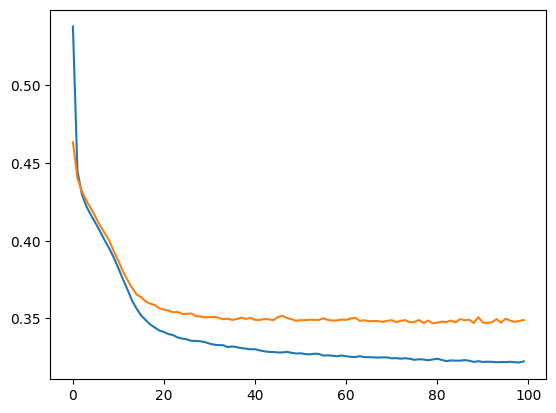

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

Text(0, 0.5, 'Accuracy')

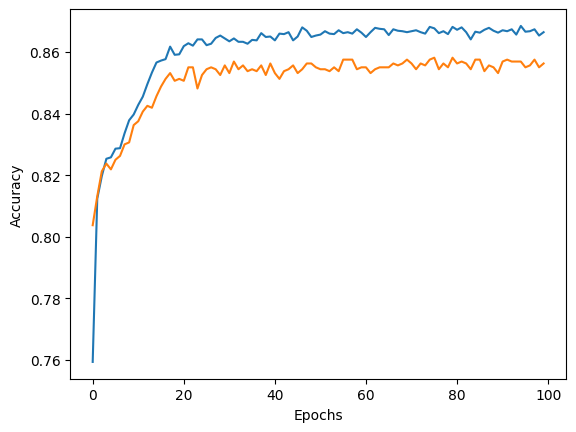

In [36]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
